In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy.interpolate import interp1d


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [85]:
# read the file: C:\Users\Sepehr\Desktop\LLM-RL\create_figures\outputs\agent_intervention_matrix_20_20_10_0.25.npy
agent_intervention_matrix = np.load('outputs/RL/agent_intervention_matrix_20_20_10_0.25.npy')
agent_intervention_matrix.shape

(10, 20, 20, 20, 2)

In [80]:
for i in range(10):
    for j in range(20):
        for k in range(20):
            for l in range(20):
                pair = agent_intervention_matrix[i, j, k, l]
                # check if pair is not [0, 0]
                if pair[0] == 2 and pair[1] == 1:
                    print(i, j, k, l, pair)
                if pair[0] == -1 and pair[1] == -1:
                    continue
                # drop nan values
                if np.isnan(pair).any():
                    continue
                # print(i, j, k, l, pair)


In [81]:
# get the number of [0, 0], [0, 2], [2, 0], [2, 2] pairs in each round and each time step (first two dimentions)
all_data = {}
for i in range(10):
    for j in range(20):
        intervention_00 = int(np.sum(agent_intervention_matrix[i, j] == [0, 0]))
        intervention_02_20 = int(np.sum(agent_intervention_matrix[i, j] == [0, 2]) + np.sum(agent_intervention_matrix[i, j] == [2, 0]))
        intervention_22 = int(np.sum(agent_intervention_matrix[i, j] == [2, 2]))
        total_interventions = intervention_00 + intervention_02_20 + intervention_22
        if total_interventions == 0:
            continue
        # this prints round number, step number, and the number of [0, 0], [0, 2] or [2, 0], [2, 2] pairs in each round and each time step
        print(i, j, intervention_00, intervention_02_20, intervention_22)
        all_data[(i, j)] = [round(intervention_00/total_interventions, 2), round(intervention_02_20/total_interventions, 2), round(intervention_22/total_interventions, 2)]
        # print the sum of all pairs in each round and each time step
    print(intervention_00 + intervention_02_20 + intervention_22)
all_data

0 0 0 236 236
0 1 0 236 236
0 2 0 236 236
0 3 0 236 236
0 4 0 236 236
0 5 0 236 236
0 6 0 236 236
0 7 0 236 236
0 8 0 236 236
0 9 0 236 236
0 10 0 236 236
0 11 0 236 236
0 12 0 236 236
0 13 0 236 236
0 14 0 236 236
0 15 0 236 236
0 16 0 236 236
0 17 0 236 236
0 18 0 236 236
0 19 0 236 236
472
1 0 0 180 180
1 1 0 180 180
1 2 0 180 180
1 3 0 180 180
1 4 0 180 180
1 5 0 180 180
1 6 0 180 180
1 7 0 180 180
1 8 0 180 180
1 9 0 180 180
1 10 0 180 180
1 11 0 180 180
1 12 0 180 180
1 13 0 180 180
1 14 0 180 180
1 15 0 180 180
1 16 0 180 180
1 17 0 180 180
1 18 0 180 180
1 19 0 180 180
360
2 0 0 200 200
2 1 0 200 200
2 2 0 200 200
2 3 0 200 200
2 4 0 200 200
2 5 0 200 200
2 6 0 200 200
2 7 0 200 200
2 8 0 200 200
2 9 0 200 200
2 10 0 200 200
2 11 0 200 200
2 12 0 200 200
2 13 0 200 200
2 14 0 200 200
2 15 0 200 200
2 16 0 200 200
2 17 0 200 200
2 18 0 200 200
2 19 0 200 200
400
3 0 0 188 188
3 1 0 188 188
3 2 0 188 188
3 3 0 188 188
3 4 0 188 188
3 5 0 188 188
3 6 0 188 188
3 7 0 188 188
3 8 0 

{(0, 0): [0.0, 0.5, 0.5],
 (0, 1): [0.0, 0.5, 0.5],
 (0, 2): [0.0, 0.5, 0.5],
 (0, 3): [0.0, 0.5, 0.5],
 (0, 4): [0.0, 0.5, 0.5],
 (0, 5): [0.0, 0.5, 0.5],
 (0, 6): [0.0, 0.5, 0.5],
 (0, 7): [0.0, 0.5, 0.5],
 (0, 8): [0.0, 0.5, 0.5],
 (0, 9): [0.0, 0.5, 0.5],
 (0, 10): [0.0, 0.5, 0.5],
 (0, 11): [0.0, 0.5, 0.5],
 (0, 12): [0.0, 0.5, 0.5],
 (0, 13): [0.0, 0.5, 0.5],
 (0, 14): [0.0, 0.5, 0.5],
 (0, 15): [0.0, 0.5, 0.5],
 (0, 16): [0.0, 0.5, 0.5],
 (0, 17): [0.0, 0.5, 0.5],
 (0, 18): [0.0, 0.5, 0.5],
 (0, 19): [0.0, 0.5, 0.5],
 (1, 0): [0.0, 0.5, 0.5],
 (1, 1): [0.0, 0.5, 0.5],
 (1, 2): [0.0, 0.5, 0.5],
 (1, 3): [0.0, 0.5, 0.5],
 (1, 4): [0.0, 0.5, 0.5],
 (1, 5): [0.0, 0.5, 0.5],
 (1, 6): [0.0, 0.5, 0.5],
 (1, 7): [0.0, 0.5, 0.5],
 (1, 8): [0.0, 0.5, 0.5],
 (1, 9): [0.0, 0.5, 0.5],
 (1, 10): [0.0, 0.5, 0.5],
 (1, 11): [0.0, 0.5, 0.5],
 (1, 12): [0.0, 0.5, 0.5],
 (1, 13): [0.0, 0.5, 0.5],
 (1, 14): [0.0, 0.5, 0.5],
 (1, 15): [0.0, 0.5, 0.5],
 (1, 16): [0.0, 0.5, 0.5],
 (1, 17): [0.0, 0.5, 

In [82]:
# show all data values with a key like (0, any)
for key, value in all_data.items():
    if key[1] == 5:
        print(key, value)

(0, 5) [0.0, 0.5, 0.5]
(1, 5) [0.0, 0.5, 0.5]
(2, 5) [0.0, 0.5, 0.5]
(3, 5) [0.0, 0.5, 0.5]
(4, 5) [0.0, 0.5, 0.5]
(5, 5) [0.0, 0.5, 0.5]
(6, 5) [0.0, 0.5, 0.5]
(7, 5) [0.0, 0.5, 0.5]
(8, 5) [0.0, 0.5, 0.5]
(9, 5) [0.0, 0.5, 0.5]


In [83]:
# now average the data over the first element of the tuple
average_data = {}
for key, value in all_data.items():
    if key[1] not in average_data:
        average_data[key[1]] = np.array(value)
    else:
        average_data[key[1]] += np.array(value)
for key in average_data:
    print(average_data[key])
    average_data[key] /= 10

# make the values of the dictionary a list
average_data = {key: value.tolist() for key, value in average_data.items()}
# round the values of the dictionary to 2 decimal points
average_data = {key: [round(value, 2) for value in value] for key, value in average_data.items()}
average_data

# add two more key, values to the data
# 0: [0, 0, 0]
# 1: [0, 0, 0]


[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]
[0. 5. 5.]


{0: [0.0, 0.5, 0.5],
 1: [0.0, 0.5, 0.5],
 2: [0.0, 0.5, 0.5],
 3: [0.0, 0.5, 0.5],
 4: [0.0, 0.5, 0.5],
 5: [0.0, 0.5, 0.5],
 6: [0.0, 0.5, 0.5],
 7: [0.0, 0.5, 0.5],
 8: [0.0, 0.5, 0.5],
 9: [0.0, 0.5, 0.5],
 10: [0.0, 0.5, 0.5],
 11: [0.0, 0.5, 0.5],
 12: [0.0, 0.5, 0.5],
 13: [0.0, 0.5, 0.5],
 14: [0.0, 0.5, 0.5],
 15: [0.0, 0.5, 0.5],
 16: [0.0, 0.5, 0.5],
 17: [0.0, 0.5, 0.5],
 18: [0.0, 0.5, 0.5],
 19: [0.0, 0.5, 0.5]}

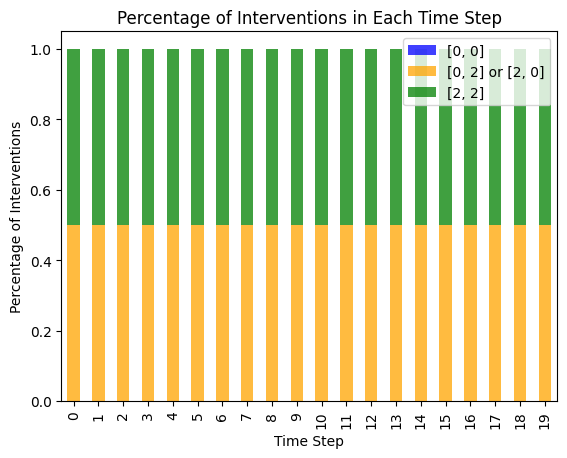

In [66]:
# draw a stacked bar plot
df = pd.DataFrame(average_data)
df = df.T
df.columns = ['[0, 0]', '[0, 2] or [2, 0]', '[2, 2]']
df.plot(kind='bar', stacked=True, color=['blue', 'orange', 'green'], alpha=0.75)
plt.xlabel('Time Step')
plt.ylabel('Percentage of Interventions')
plt.title('Percentage of Interventions in Each Time Step')
plt.show()

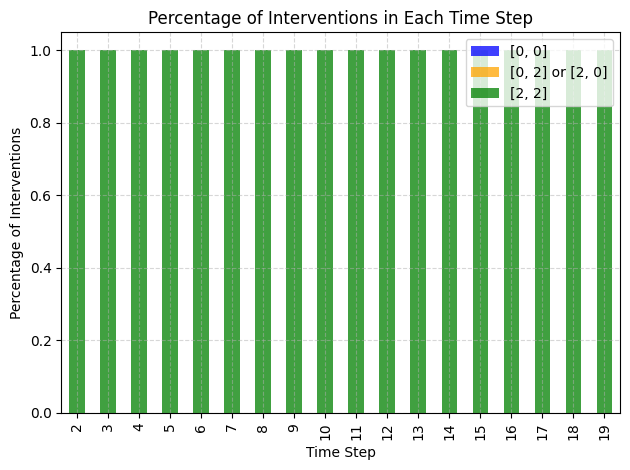

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- COUNT interventions ---
all_data = {}

for i in range(10):  # 10 rounds
    for j in range(20):  # 20 steps
        interventions = agent_intervention_matrix[i, j]  # assume shape (n_pairs, 2)
        
        if interventions.size == 0:
            continue
        
        intervention_00 = np.sum((interventions[:,0] == 0) & (interventions[:,1] == 0))
        intervention_02_20 = np.sum((interventions[:,0] == 0) & (interventions[:,1] == 2)) + np.sum((interventions[:,0] == 2) & (interventions[:,1] == 0))
        intervention_22 = np.sum((interventions[:,0] == 2) & (interventions[:,1] == 2))
        
        total_interventions = intervention_00 + intervention_02_20 + intervention_22
        
        if total_interventions == 0:
            continue
        
        all_data[(i, j)] = [
            round(intervention_00 / total_interventions, 2),
            round(intervention_02_20 / total_interventions, 2),
            round(intervention_22 / total_interventions, 2)
        ]

# --- AVERAGE across rounds (first index) ---
average_data = {}
for key, value in all_data.items():
    step = key[1]
    if step not in average_data:
        average_data[step] = np.array(value)
    else:
        average_data[step] += np.array(value)

# Now divide by the number of rounds that contributed
# Important: You have to divide by the correct number of rounds **that had data** for each step
# Otherwise steps with no intervention will have wrong averages

# Find number of rounds that contributed to each time step
step_counts = {}
for (i, j) in all_data.keys():
    if j not in step_counts:
        step_counts[j] = 1
    else:
        step_counts[j] += 1

# Divide properly
for key in average_data:
    average_data[key] /= step_counts[key]

# Round nicely
average_data = {key: [round(val, 2) for val in value.tolist()] for key, value in average_data.items()}

# --- BUILD the DataFrame ---
df = pd.DataFrame.from_dict(average_data, orient='index')
df.columns = ['[0, 0]', '[0, 2] or [2, 0]', '[2, 2]']

# Sort index to make sure time steps are ordered
df = df.sort_index()

# Optionally, reindex to cover steps 2-19 if you want full 18 bars
# (Fill missing steps with zeros)
df = df.reindex(range(2, 20), fill_value=0)

# --- PLOT ---
df.plot(kind='bar', stacked=True, color=['blue', 'orange', 'green'], alpha=0.75)
plt.xlabel('Time Step')
plt.ylabel('Percentage of Interventions')
plt.title('Percentage of Interventions in Each Time Step')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
